In [1]:
# 1. Convertir una imagen a blanco y negro manualmente con NumPy
import cv2
import numpy as np

img = cv2.imread("oficina.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Manualmente: aplicar un umbral con NumPy
bw = np.where(gray > 127, 255, 0).astype(np.uint8)

cv2.imshow("Blanco y negro (manual)", bw)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [2]:
#2. Desenfoque selectivo con máscara hecha con NumPy
import cv2
import numpy as np

img = cv2.imread("oficina.jpg")
mask = np.zeros(img.shape[:2], dtype=np.uint8)

# Crear un círculo blanco en el centro
cv2.circle(mask, (img.shape[1]//2, img.shape[0]//2), 100, 255, -1)

# Aplicar desenfoque total
blurred = cv2.GaussianBlur(img, (51, 51), 0)

# Usar la máscara para combinar las imágenes
result = np.where(mask[:, :, np.newaxis] == 255, img, blurred)

cv2.imshow("Enfoque selectivo", result)
cv2.waitKey(0)
cv2.destroyAllWindows()


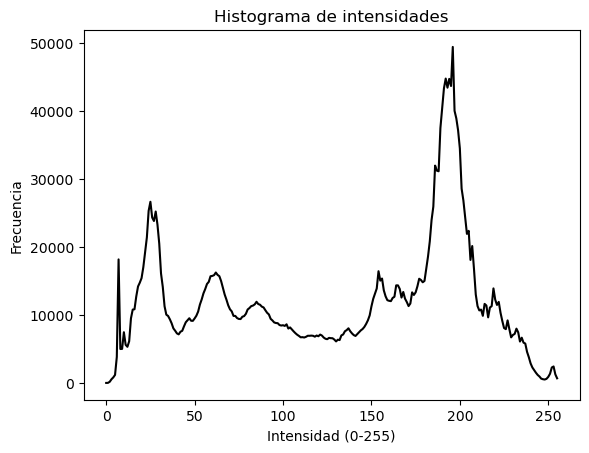

In [4]:
# 3. Histograma de imagen en escala de grises con NumPy

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("oficina.jpg", cv2.IMREAD_GRAYSCALE)

# Calcular histograma (valores de 0 a 255)
hist = np.bincount(img.ravel(), minlength=256)

plt.plot(hist, color='black')
plt.title("Histograma de intensidades")
plt.xlabel("Intensidad (0-255)")
plt.ylabel("Frecuencia")
plt.show()

In [1]:
# 4. Detección de bordes con Sobel usando NumPy directamente
import cv2
import numpy as np

img = cv2.imread("oficina.jpg", cv2.IMREAD_GRAYSCALE)

# Filtros Sobel (horizontal y vertical)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

grad_x = cv2.filter2D(img, -1, sobel_x)
grad_y = cv2.filter2D(img, -1, sobel_y)

# Magnitud del gradiente
magnitude = np.sqrt(grad_x.astype(float)**2 + grad_y.astype(float)**2)
magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

cv2.imshow("Bordes (Sobel)", magnitude)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [2]:
# 6. Crear una imagen tipo código QR falso con NumPy
import numpy as np
import cv2

# Crear patrón binario
pattern = np.random.choice([0, 255], size=(21, 21), p=[0.5, 0.5]).astype(np.uint8)

# Escalarlo a tamaño visible (por ejemplo, 10x)
qr_fake = np.kron(pattern, np.ones((10, 10), dtype=np.uint8))

cv2.imshow("QR falso", qr_fake)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [3]:
import cv2
import numpy as np

# Intentar abrir la webcam (usa 0, 1 o 2 según el sistema)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Error: No se pudo abrir la cámara.")
    exit()

# Leer el primer frame
ret, frame1 = cap.read()
if not ret:
    print("❌ Error: No se pudo leer el primer frame.")
    cap.release()
    exit()

# Preprocesar primer frame
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray1 = cv2.GaussianBlur(gray1, (21, 21), 0)

while True:
    # Capturar siguiente frame
    ret, frame2 = cap.read()
    if not ret:
        print("⚠️ Advertencia: No se pudo leer el siguiente frame.")
        break

    # Convertir a gris y aplicar desenfoque
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.GaussianBlur(gray2, (21, 21), 0)

    # Comparar frames
    delta = cv2.absdiff(gray1, gray2)
    _, thresh = cv2.threshold(delta, 25, 255, cv2.THRESH_BINARY)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Detectar contornos de zonas con cambio
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Dibujar rectángulos si el área del cambio es significativa
    for contour in contours:
        if cv2.contourArea(contour) < 1000:
            continue
        (x, y, w, h) = cv2.boundingRect(contour)
        cv2.rectangle(frame2, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Mostrar el resultado
    cv2.imshow("Detección de Movimiento", frame2)

    key = cv2.waitKey(30)
    if key == 27:  # ESC para salir
        break

    # Actualizar el frame anterior
    gray1 = gray2

cap.release()
cv2.destroyAllWindows()


KeyboardInterrupt: 